## train_mlp

Ten notebook robi dwa etapy:
1. sanity check: overfit na bardzo małym zbiorze `train_random_tiny.csv`
2. pełny trening MLP na:
   - random split
   - scaffold split


## 1. Importy

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch

from mlp_model import (
    MLPRegressor,
    dataframe_to_fingerprints,
    evaluate,
    fit_model,
    init_mlp_weights,
    make_dataloader,
    set_seed,
)

DATA_DIR = Path("prepared_data")
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

set_seed(SEED)
print("Device:", DEVICE)


Device: cpu


## 2. Wczytanie plików

In [7]:
train_random_tiny = pd.read_csv(DATA_DIR / "train_random_tiny.csv")

train_random = pd.read_csv(DATA_DIR / "train_random.csv")
val_random = pd.read_csv(DATA_DIR / "val_random.csv")
test_random = pd.read_csv(DATA_DIR / "test_random.csv")

train_scaffold = pd.read_csv(DATA_DIR / "train_scaffold.csv")
val_scaffold = pd.read_csv(DATA_DIR / "val_scaffold.csv")
test_scaffold = pd.read_csv(DATA_DIR / "test_scaffold.csv")

print("tiny:", train_random_tiny.shape)
print("random train/val/test:", train_random.shape, val_random.shape, test_random.shape)
print("scaffold train/val/test:", train_scaffold.shape, val_scaffold.shape, test_scaffold.shape)


tiny: (128, 9)
random train/val/test: (7520, 9) (940, 9) (940, 9)
scaffold train/val/test: (7520, 10) (940, 10) (940, 10)


## 3. Featuryzacja tiny subsetu

In [8]:
X_tiny, y_tiny, tiny_valid = dataframe_to_fingerprints(
    train_random_tiny,
    smiles_col="canonical_smiles",
    target_col="y",
    radius=2,
    n_bits=2048,
)

print("Tiny valid rows:", tiny_valid.shape)
print("X_tiny:", X_tiny.shape, "y_tiny:", y_tiny.shape)


Tiny valid rows: (128, 9)
X_tiny: (128, 2048) y_tiny: (128, 1)


[22:59:00] DEPRECATION WARNING: please use MorganGenerator
[22:59:00] DEPRECATION WARNING: please use MorganGenerator
[22:59:00] DEPRECATION WARNING: please use MorganGenerator
[22:59:00] DEPRECATION WARNING: please use MorganGenerator
[22:59:00] DEPRECATION WARNING: please use MorganGenerator
[22:59:00] DEPRECATION WARNING: please use MorganGenerator
[22:59:00] DEPRECATION WARNING: please use MorganGenerator
[22:59:00] DEPRECATION WARNING: please use MorganGenerator
[22:59:00] DEPRECATION WARNING: please use MorganGenerator
[22:59:00] DEPRECATION WARNING: please use MorganGenerator
[22:59:00] DEPRECATION WARNING: please use MorganGenerator
[22:59:00] DEPRECATION WARNING: please use MorganGenerator
[22:59:00] DEPRECATION WARNING: please use MorganGenerator
[22:59:00] DEPRECATION WARNING: please use MorganGenerator
[22:59:00] DEPRECATION WARNING: please use MorganGenerator
[22:59:00] DEPRECATION WARNING: please use MorganGenerator
[22:59:00] DEPRECATION WARNING: please use MorganGenerat

## 4. Overfit sanity check na tiny subset

In [9]:
tiny_loader = make_dataloader(
    X_tiny,
    y_tiny,
    batch_size=min(32, len(X_tiny)),
    shuffle=True,
)

tiny_model = MLPRegressor(
    input_dim=2048,
    hidden_dims=(512, 128),
    dropout=0.0,
)
tiny_model.apply(init_mlp_weights)

tiny_model, tiny_history = fit_model(
    tiny_model,
    tiny_loader,
    tiny_loader,
    epochs=200,
    lr=1e-3,
    weight_decay=0.0,
    device=DEVICE,
    verbose=True,
)

tiny_history.tail()


Epoch 001 | train_loss=38.5784 | val_loss=12.5314 | train_rmse=6.2112 | val_rmse=3.5400
Epoch 002 | train_loss=6.0914 | val_loss=6.3440 | train_rmse=2.4681 | val_rmse=2.5187
Epoch 003 | train_loss=6.7746 | val_loss=2.4184 | train_rmse=2.6028 | val_rmse=1.5551
Epoch 004 | train_loss=1.1817 | val_loss=1.3311 | train_rmse=1.0870 | val_rmse=1.1537
Epoch 005 | train_loss=2.0322 | val_loss=2.1540 | train_rmse=1.4256 | val_rmse=1.4676
Epoch 006 | train_loss=1.5404 | val_loss=0.4528 | train_rmse=1.2411 | val_rmse=0.6729
Epoch 007 | train_loss=0.4062 | val_loss=0.7045 | train_rmse=0.6373 | val_rmse=0.8394
Epoch 008 | train_loss=0.8102 | val_loss=0.5170 | train_rmse=0.9001 | val_rmse=0.7190
Epoch 009 | train_loss=0.2753 | val_loss=0.1399 | train_rmse=0.5247 | val_rmse=0.3740
Epoch 010 | train_loss=0.2351 | val_loss=0.3175 | train_rmse=0.4849 | val_rmse=0.5634
Epoch 011 | train_loss=0.2426 | val_loss=0.0815 | train_rmse=0.4926 | val_rmse=0.2855
Epoch 012 | train_loss=0.0797 | val_loss=0.1178 | tr

,epoch,train_loss,train_rmse,train_mae,train_r2,val_loss,val_rmse,val_mae,val_r2
195,196,2.842171e-14,1.685874e-07,4.470348e-08,1.0,3.019807e-14,1.737759e-07,4.842877e-08,1.0
196,197,4.440892e-14,2.107342e-07,6.332994e-08,1.0,1.598721e-14,1.264405e-07,2.607703e-08,1.0
197,198,1.953993e-14,1.397853e-07,3.352761e-08,1.0,2.486900e-14,1.576991e-07,3.725290e-08,1.0
198,199,4.085621e-14,2.021292e-07,5.587935e-08,1.0,2.842171e-14,1.685874e-07,3.725290e-08,1.0
199,200,2.486900e-14,1.576991e-07,3.725290e-08,1.0,2.309264e-14,1.519626e-07,4.097819e-08,1.0


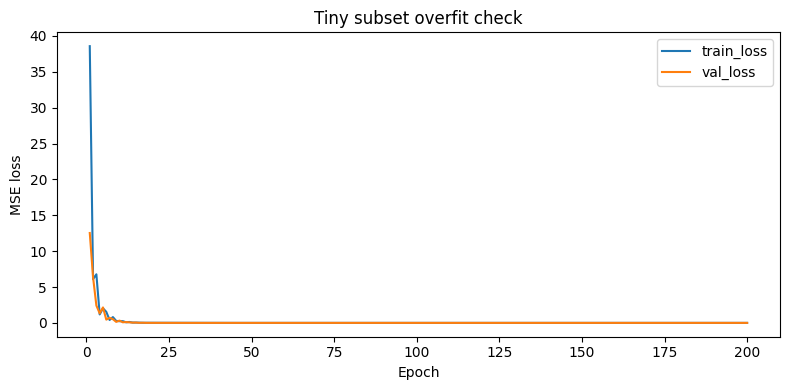

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(tiny_history["epoch"], tiny_history["train_loss"], label="train_loss")
plt.plot(tiny_history["epoch"], tiny_history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Tiny subset overfit check")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Featuryzacja random split

In [12]:
X_train_r, y_train_r, train_random_valid = dataframe_to_fingerprints(train_random)
X_val_r, y_val_r, val_random_valid = dataframe_to_fingerprints(val_random)
X_test_r, y_test_r, test_random_valid = dataframe_to_fingerprints(test_random)

print(X_train_r.shape, y_train_r.shape)
print(X_val_r.shape, y_val_r.shape)
print(X_test_r.shape, y_test_r.shape)


[23:05:31] DEPRECATION WARNING: please use MorganGenerator
[23:05:31] DEPRECATION WARNING: please use MorganGenerator
[23:05:31] DEPRECATION WARNING: please use MorganGenerator
[23:05:31] DEPRECATION WARNING: please use MorganGenerator
[23:05:31] DEPRECATION WARNING: please use MorganGenerator
[23:05:31] DEPRECATION WARNING: please use MorganGenerator
[23:05:31] DEPRECATION WARNING: please use MorganGenerator
[23:05:31] DEPRECATION WARNING: please use MorganGenerator
[23:05:31] DEPRECATION WARNING: please use MorganGenerator
[23:05:31] DEPRECATION WARNING: please use MorganGenerator
[23:05:31] DEPRECATION WARNING: please use MorganGenerator
[23:05:31] DEPRECATION WARNING: please use MorganGenerator
[23:05:31] DEPRECATION WARNING: please use MorganGenerator
[23:05:31] DEPRECATION WARNING: please use MorganGenerator
[23:05:31] DEPRECATION WARNING: please use MorganGenerator
[23:05:31] DEPRECATION WARNING: please use MorganGenerator
[23:05:31] DEPRECATION WARNING: please use MorganGenerat

(7520, 2048) (7520, 1)
(940, 2048) (940, 1)
(940, 2048) (940, 1)


[23:05:38] DEPRECATION WARNING: please use MorganGenerator
[23:05:38] DEPRECATION WARNING: please use MorganGenerator


## 6. Trening MLP na random split

In [13]:
train_loader_r = make_dataloader(X_train_r, y_train_r, batch_size=64, shuffle=True)
val_loader_r = make_dataloader(X_val_r, y_val_r, batch_size=256, shuffle=False)
test_loader_r = make_dataloader(X_test_r, y_test_r, batch_size=256, shuffle=False)

model_random = MLPRegressor(
    input_dim=2048,
    hidden_dims=(512, 128),
    dropout=0.2,
)
model_random.apply(init_mlp_weights)

model_random, history_random = fit_model(
    model_random,
    train_loader_r,
    val_loader_r,
    epochs=50,
    lr=1e-3,
    weight_decay=0.0,
    device=DEVICE,
    verbose=True,
)

criterion = torch.nn.MSELoss()
test_random_result = evaluate(model_random, test_loader_r, criterion, DEVICE)
test_random_result


Epoch 001 | train_loss=3.8972 | val_loss=0.7666 | train_rmse=1.9741 | val_rmse=0.8756
Epoch 002 | train_loss=1.1163 | val_loss=0.7686 | train_rmse=1.0565 | val_rmse=0.8767
Epoch 003 | train_loss=0.9873 | val_loss=0.6890 | train_rmse=0.9936 | val_rmse=0.8301
Epoch 004 | train_loss=0.9002 | val_loss=0.6860 | train_rmse=0.9488 | val_rmse=0.8283
Epoch 005 | train_loss=0.8461 | val_loss=0.6067 | train_rmse=0.9198 | val_rmse=0.7789
Epoch 006 | train_loss=0.8438 | val_loss=0.6652 | train_rmse=0.9186 | val_rmse=0.8156
Epoch 007 | train_loss=0.7862 | val_loss=0.7578 | train_rmse=0.8867 | val_rmse=0.8705
Epoch 008 | train_loss=0.7178 | val_loss=0.5534 | train_rmse=0.8472 | val_rmse=0.7439
Epoch 009 | train_loss=0.6768 | val_loss=0.6217 | train_rmse=0.8227 | val_rmse=0.7885
Epoch 010 | train_loss=0.6930 | val_loss=0.6403 | train_rmse=0.8324 | val_rmse=0.8002
Epoch 011 | train_loss=0.6708 | val_loss=0.5871 | train_rmse=0.8190 | val_rmse=0.7662
Epoch 012 | train_loss=0.6553 | val_loss=0.7362 | trai

EpochResult(loss=0.5012671295632707, rmse=0.7080022140807753, mae=0.529978334903717, r2=0.6403821063709425)

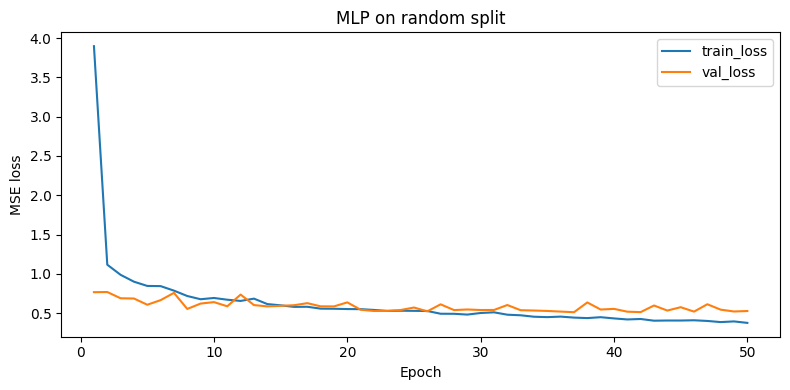

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(history_random["epoch"], history_random["train_loss"], label="train_loss")
plt.plot(history_random["epoch"], history_random["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("MLP on random split")
plt.legend()
plt.tight_layout()
plt.show()


## 7. Featuryzacja scaffold split

In [15]:
X_train_s, y_train_s, train_scaffold_valid = dataframe_to_fingerprints(train_scaffold)
X_val_s, y_val_s, val_scaffold_valid = dataframe_to_fingerprints(val_scaffold)
X_test_s, y_test_s, test_scaffold_valid = dataframe_to_fingerprints(test_scaffold)

print(X_train_s.shape, y_train_s.shape)
print(X_val_s.shape, y_val_s.shape)
print(X_test_s.shape, y_test_s.shape)


[23:07:10] DEPRECATION WARNING: please use MorganGenerator
[23:07:10] DEPRECATION WARNING: please use MorganGenerator
[23:07:10] DEPRECATION WARNING: please use MorganGenerator
[23:07:10] DEPRECATION WARNING: please use MorganGenerator
[23:07:10] DEPRECATION WARNING: please use MorganGenerator
[23:07:10] DEPRECATION WARNING: please use MorganGenerator
[23:07:10] DEPRECATION WARNING: please use MorganGenerator
[23:07:10] DEPRECATION WARNING: please use MorganGenerator
[23:07:10] DEPRECATION WARNING: please use MorganGenerator
[23:07:10] DEPRECATION WARNING: please use MorganGenerator
[23:07:10] DEPRECATION WARNING: please use MorganGenerator
[23:07:10] DEPRECATION WARNING: please use MorganGenerator
[23:07:10] DEPRECATION WARNING: please use MorganGenerator
[23:07:10] DEPRECATION WARNING: please use MorganGenerator
[23:07:10] DEPRECATION WARNING: please use MorganGenerator
[23:07:10] DEPRECATION WARNING: please use MorganGenerator
[23:07:10] DEPRECATION WARNING: please use MorganGenerat

(7520, 2048) (7520, 1)
(940, 2048) (940, 1)
(940, 2048) (940, 1)


[23:07:17] DEPRECATION WARNING: please use MorganGenerator
[23:07:17] DEPRECATION WARNING: please use MorganGenerator
[23:07:17] DEPRECATION WARNING: please use MorganGenerator
[23:07:17] DEPRECATION WARNING: please use MorganGenerator
[23:07:17] DEPRECATION WARNING: please use MorganGenerator
[23:07:17] DEPRECATION WARNING: please use MorganGenerator
[23:07:17] DEPRECATION WARNING: please use MorganGenerator
[23:07:17] DEPRECATION WARNING: please use MorganGenerator
[23:07:17] DEPRECATION WARNING: please use MorganGenerator
[23:07:17] DEPRECATION WARNING: please use MorganGenerator
[23:07:17] DEPRECATION WARNING: please use MorganGenerator
[23:07:17] DEPRECATION WARNING: please use MorganGenerator
[23:07:17] DEPRECATION WARNING: please use MorganGenerator
[23:07:17] DEPRECATION WARNING: please use MorganGenerator
[23:07:17] DEPRECATION WARNING: please use MorganGenerator
[23:07:17] DEPRECATION WARNING: please use MorganGenerator
[23:07:17] DEPRECATION WARNING: please use MorganGenerat

## 8. Trening MLP na scaffold split

In [16]:
train_loader_s = make_dataloader(X_train_s, y_train_s, batch_size=64, shuffle=True)
val_loader_s = make_dataloader(X_val_s, y_val_s, batch_size=256, shuffle=False)
test_loader_s = make_dataloader(X_test_s, y_test_s, batch_size=256, shuffle=False)

model_scaffold = MLPRegressor(
    input_dim=2048,
    hidden_dims=(512, 128),
    dropout=0.2,
)
model_scaffold.apply(init_mlp_weights)

model_scaffold, history_scaffold = fit_model(
    model_scaffold,
    train_loader_s,
    val_loader_s,
    epochs=50,
    lr=1e-3,
    weight_decay=0.0,
    device=DEVICE,
    verbose=True,
)

criterion = torch.nn.MSELoss()
test_scaffold_result = evaluate(model_scaffold, test_loader_s, criterion, DEVICE)
test_scaffold_result


Epoch 001 | train_loss=3.3353 | val_loss=1.0091 | train_rmse=1.8263 | val_rmse=1.0045
Epoch 002 | train_loss=0.9875 | val_loss=0.9242 | train_rmse=0.9938 | val_rmse=0.9614
Epoch 003 | train_loss=0.8925 | val_loss=0.9433 | train_rmse=0.9447 | val_rmse=0.9713
Epoch 004 | train_loss=0.8310 | val_loss=1.0400 | train_rmse=0.9116 | val_rmse=1.0198
Epoch 005 | train_loss=0.7959 | val_loss=0.9770 | train_rmse=0.8921 | val_rmse=0.9884
Epoch 006 | train_loss=0.7465 | val_loss=0.9291 | train_rmse=0.8640 | val_rmse=0.9639
Epoch 007 | train_loss=0.7260 | val_loss=0.9326 | train_rmse=0.8520 | val_rmse=0.9657
Epoch 008 | train_loss=0.6944 | val_loss=0.9164 | train_rmse=0.8333 | val_rmse=0.9573
Epoch 009 | train_loss=0.6997 | val_loss=0.9220 | train_rmse=0.8365 | val_rmse=0.9602
Epoch 010 | train_loss=0.6865 | val_loss=0.8874 | train_rmse=0.8286 | val_rmse=0.9420
Epoch 011 | train_loss=0.6573 | val_loss=0.9098 | train_rmse=0.8108 | val_rmse=0.9538
Epoch 012 | train_loss=0.6385 | val_loss=0.9116 | trai

EpochResult(loss=0.8659636274297187, rmse=0.9305717046168295, mae=0.6819058060646057, r2=0.3530165007407724)

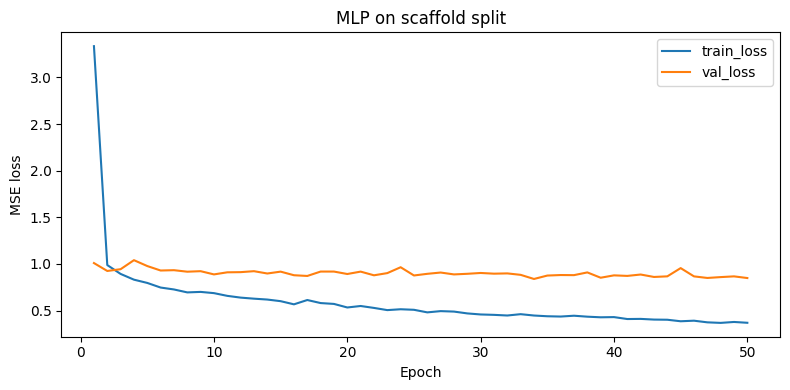

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(history_scaffold["epoch"], history_scaffold["train_loss"], label="train_loss")
plt.plot(history_scaffold["epoch"], history_scaffold["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("MLP on scaffold split")
plt.legend()
plt.tight_layout()
plt.show()


## 9. Krótkie porównanie wyników

In [18]:
results = pd.DataFrame([
    {
        "split": "random",
        "test_loss": test_random_result.loss,
        "test_rmse": test_random_result.rmse,
        "test_mae": test_random_result.mae,
        "test_r2": test_random_result.r2,
    },
    {
        "split": "scaffold",
        "test_loss": test_scaffold_result.loss,
        "test_rmse": test_scaffold_result.rmse,
        "test_mae": test_scaffold_result.mae,
        "test_r2": test_scaffold_result.r2,
    },
])

results


,split,test_loss,test_rmse,test_mae,test_r2
0,random,0.501267,0.708002,0.529978,0.640382
1,scaffold,0.865964,0.930572,0.681906,0.353017
